# SHAP Analysis and Fairness Audit

# Setup and Loading

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Install shap if needed
# !pip install shap --quiet
import shap

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from scipy import stats

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

In [32]:
# Load the saved model artifacts
model = joblib.load('original_airbnb_model.pkl')
scaler = joblib.load('original_scaler.pkl')
feature_columns = joblib.load('original_feature_columns.pkl')
feature_defaults = joblib.load('feature_defaults.pkl')

In [33]:
print(f"Model type: {type(model).__name__}")
print(f"Number of features: {len(feature_columns)}")

Model type: XGBRegressor
Number of features: 214


In [34]:
# Load processed data
df = pd.read_csv('airbnb_processed_data.csv')
print(f"\nDataset shape: {df.shape}")

# Reconstruct the same train/test split as the ML notebook
target_col = 'price'
X = df.drop(columns=[target_col])
y = df[target_col]

# Remove price_per_person - same leakage fix as ML notebook
if 'price_per_person' in X.columns:
    X = X.drop(columns=['price_per_person'])

# Keep only the feature columns the model was trained on
existing_features = [col for col in feature_columns if col in X.columns]
missing_features = [col for col in feature_columns if col not in X.columns]



Dataset shape: (4988, 216)


In [35]:
if missing_features:
    print(f"Warning: {len(missing_features)} features not found in processed data: {missing_features[:5]}")

X = X[existing_features]

# Drop rows with missing target
valid_mask = y.notna()
X = X[valid_mask]
y = y[valid_mask]

X = X.fillna(X.median())

In [36]:
# Recreate the same split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
X_train_scaled = pd.DataFrame(
    scaler.transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [37]:
# Confirm model performance matches what we expect
y_test_pred = model.predict(X_test_scaled)
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"\nModel performance confirmed:")
print(f"Test R²:   {test_r2:.4f}")
print(f"Test RMSE: £{test_rmse:.2f}")


Model performance confirmed:
Test R²:   0.4910
Test RMSE: £58.21


### SHAP Analysis

In [38]:
# Use a background sample for the explainer - 100 samples is enough for TreeExplainer
# TreeExplainer is the fast, exact method for XGBoost
background_sample = X_train_scaled.sample(100, random_state=42)

explainer = shap.TreeExplainer(model, background_sample)
print("SHAP TreeExplainer created")


SHAP TreeExplainer created


In [39]:
# Calculate SHAP values for the test set
# Use a sample of 500 to keep it manageable
np.random.seed(42)
sample_idx = np.random.choice(len(X_test_scaled), size=500, replace=False)
X_test_sample = X_test_scaled.iloc[sample_idx]
y_test_sample = y_test.iloc[sample_idx]

print("Calculating SHAP values for 500 test listings...")
shap_values = explainer(X_test_sample)
print("Done")

# Also get raw array for some plots
shap_array = shap_values.values
expected_value = explainer.expected_value

print(f"\nSHAP base value (average prediction): £{expected_value:.2f}")
print(f"Actual test set mean price: £{y_test.mean():.2f}")

Calculating SHAP values for 500 test listings...
Done

SHAP base value (average prediction): £97.92
Actual test set mean price: £95.97


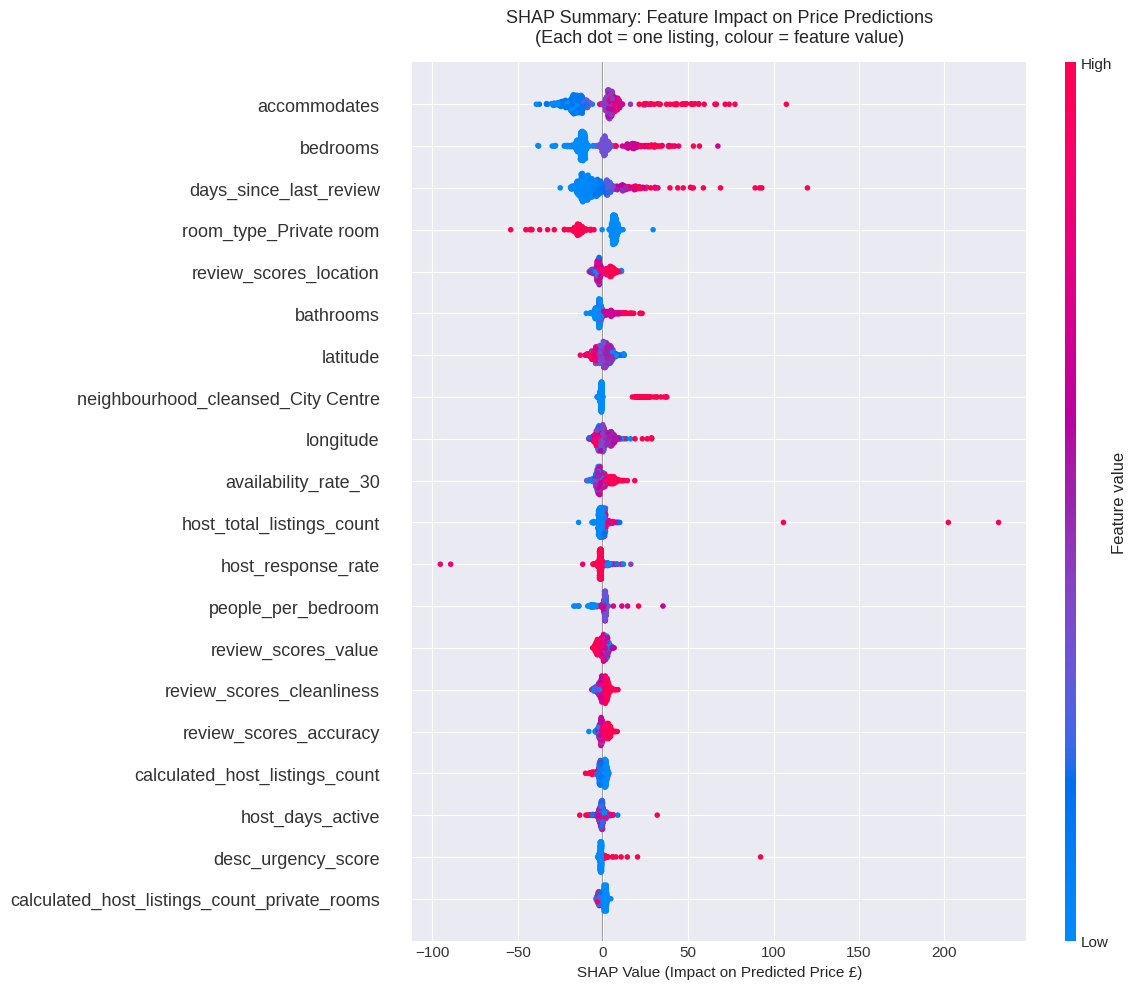

Saved: shap_summary_beeswarm.png


In [40]:
"""### SHAP Summary Plot - Global Feature Impact"""

# Beeswarm plot - shows distribution of SHAP values for each feature
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values,
    X_test_sample,
    max_display=20,
    show=False,
    plot_size=None
)
plt.title('SHAP Summary: Feature Impact on Price Predictions\n(Each dot = one listing, colour = feature value)',
          fontsize=13, pad=15)
plt.xlabel('SHAP Value (Impact on Predicted Price £)', fontsize=11)
plt.tight_layout()
plt.savefig('shap_summary_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary_beeswarm.png")

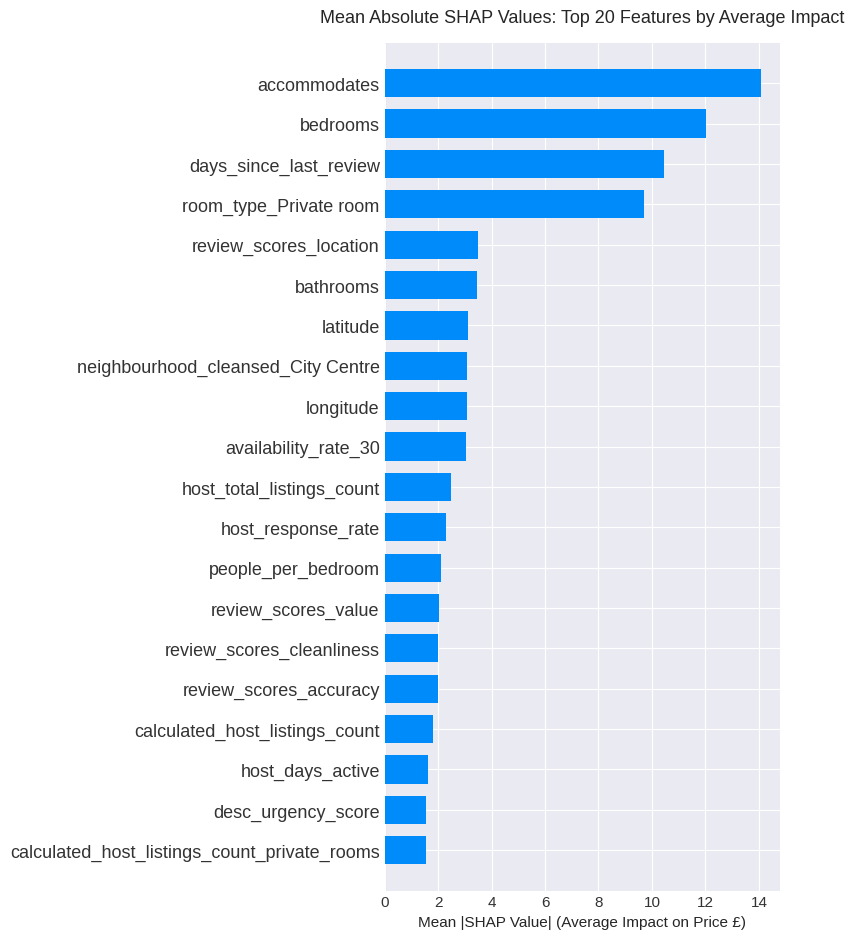

Saved: shap_summary_bar.png


In [41]:
"""### SHAP Bar Chart - Mean Absolute Impact"""

# Bar chart showing average magnitude of impact
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_array,
    X_test_sample,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title('Mean Absolute SHAP Values: Top 20 Features by Average Impact', fontsize=13, pad=15)
plt.xlabel('Mean |SHAP Value| (Average Impact on Price £)', fontsize=11)
plt.tight_layout()
plt.savefig('shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary_bar.png")

In [42]:
# Print the top 15 features by mean absolute SHAP value
mean_shap = pd.DataFrame({
    'feature': X_test_sample.columns,
    'mean_abs_shap': np.abs(shap_array).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("\nTop 15 Features by Mean Absolute SHAP Value:")
print("-" * 50)
for i, row in mean_shap.head(15).iterrows():
    print(f"{row['feature']:.<42} £{row['mean_abs_shap']:.2f}")


Top 15 Features by Mean Absolute SHAP Value:
--------------------------------------------------
accommodates.............................. £14.09
bedrooms.................................. £12.02
days_since_last_review.................... £10.45
room_type_Private room.................... £9.72
review_scores_location.................... £3.48
bathrooms................................. £3.44
latitude.................................. £3.11
neighbourhood_cleansed_City Centre........ £3.10
longitude................................. £3.09
availability_rate_30...................... £3.05
host_total_listings_count................. £2.47
host_response_rate........................ £2.29
people_per_bedroom........................ £2.11
review_scores_value....................... £2.03
review_scores_cleanliness................. £2.00


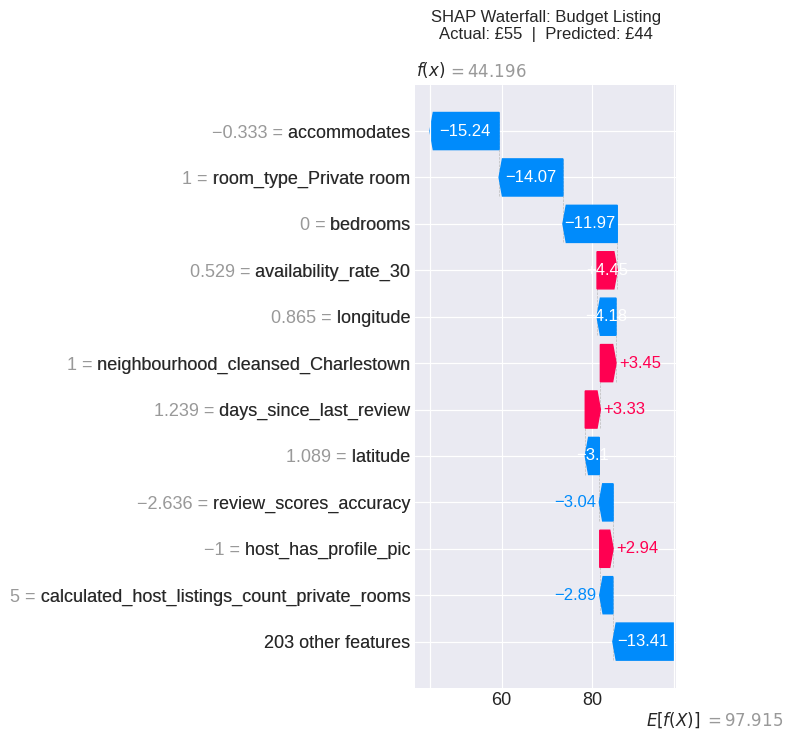

Saved: shap_waterfall_budget_listing.png
   Actual price: £55.00
   Predicted price: £44.20
   Prediction error: £10.80



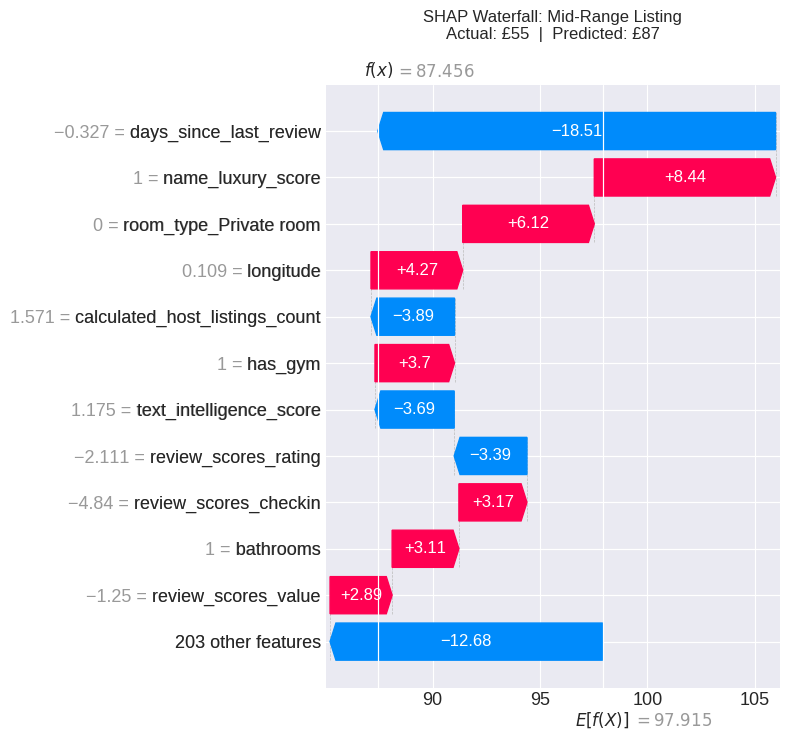

Saved: shap_waterfall_mid-range_listing.png
   Actual price: £55.00
   Predicted price: £87.46
   Prediction error: £32.46



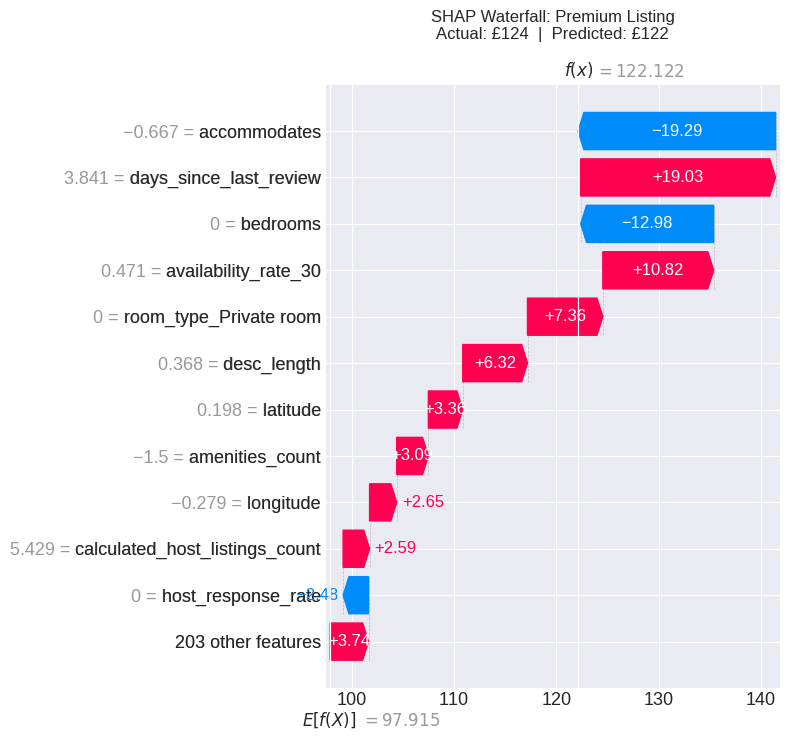

Saved: shap_waterfall_premium_listing.png
   Actual price: £124.00
   Predicted price: £122.12
   Prediction error: £1.88



In [43]:
# SHAP Waterfall Charts - Individual Listing Explanations

# Select three representative listings: budget, mid-range, and premium
pred_prices = model.predict(X_test_sample)
pred_series = pd.Series(pred_prices, index=X_test_sample.index)

# Find listings closest to the 20th, 50th and 80th percentile predictions
p20 = pred_series.quantile(0.20)
p50 = pred_series.quantile(0.50)
p80 = pred_series.quantile(0.80)

idx_budget = (pred_series - p20).abs().idxmin()
idx_midrange = (pred_series - p50).abs().idxmin()
idx_premium = (pred_series - p80).abs().idxmin()

listing_examples = {
    'Budget Listing': idx_budget,
    'Mid-Range Listing': idx_midrange,
    'Premium Listing': idx_premium
}

for label, idx in listing_examples.items():
    pos = X_test_sample.index.get_loc(idx)
    actual = y_test_sample.loc[idx]
    predicted = pred_series.loc[idx]

    plt.figure(figsize=(14, 6))
    shap.waterfall_plot(shap_values[pos], max_display=12, show=False)
    plt.title(f'SHAP Waterfall: {label}\nActual: £{actual:.0f}  |  Predicted: £{predicted:.0f}',
              fontsize=12, pad=15)
    plt.tight_layout()
    filename = f"shap_waterfall_{label.lower().replace(' ', '_')}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")
    print(f"   Actual price: £{actual:.2f}")
    print(f"   Predicted price: £{predicted:.2f}")
    print(f"   Prediction error: £{abs(actual - predicted):.2f}\n")

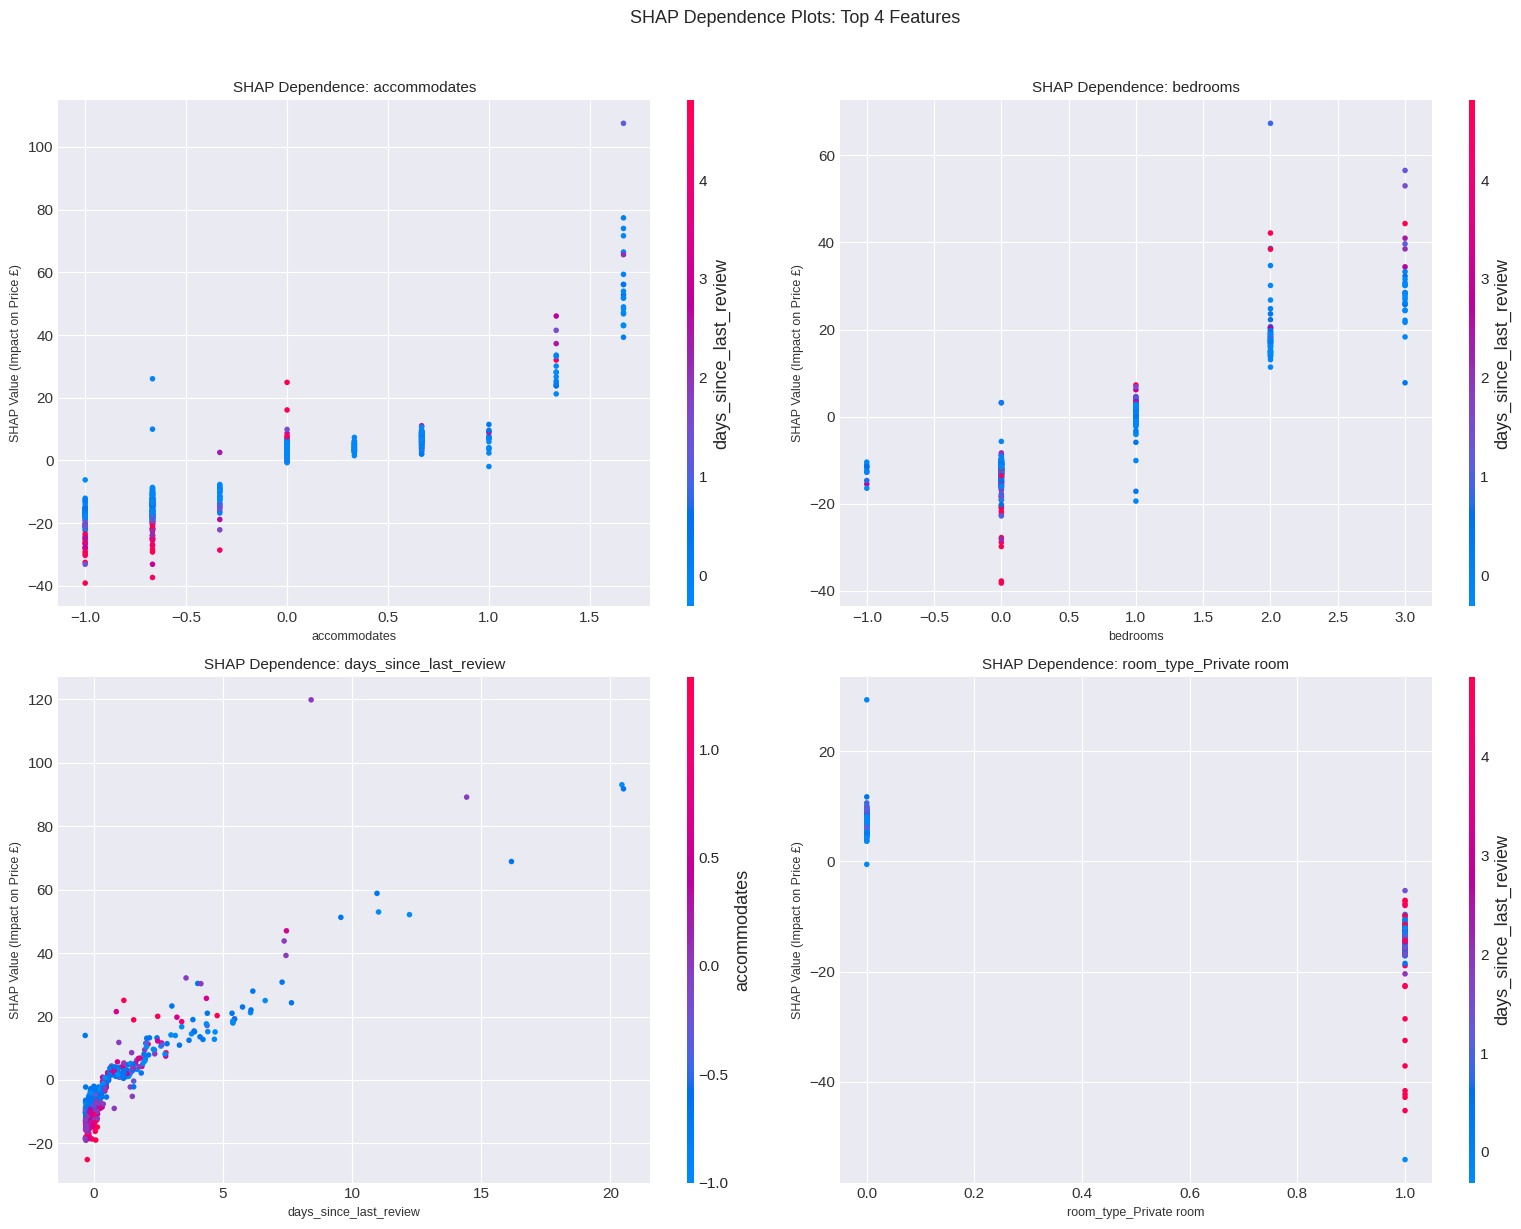

Saved: shap_dependence_plots.png


In [44]:
"""### SHAP Dependence Plots - How Top Features Relate to Price

Dependence plots show how a single feature's SHAP value changes across its range.
The colour shows the interaction with the most correlated other feature.
"""

top_features = mean_shap.head(4)['feature'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    if feature in X_test_sample.columns:
        shap.dependence_plot(
            feature,
            shap_array,
            X_test_sample,
            ax=axes[i],
            show=False
        )
        axes[i].set_title(f'SHAP Dependence: {feature}', fontsize=11)
        axes[i].set_ylabel('SHAP Value (Impact on Price £)', fontsize=9)
        axes[i].set_xlabel(feature, fontsize=9)

plt.suptitle('SHAP Dependence Plots: Top 4 Features', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('shap_dependence_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_dependence_plots.png")

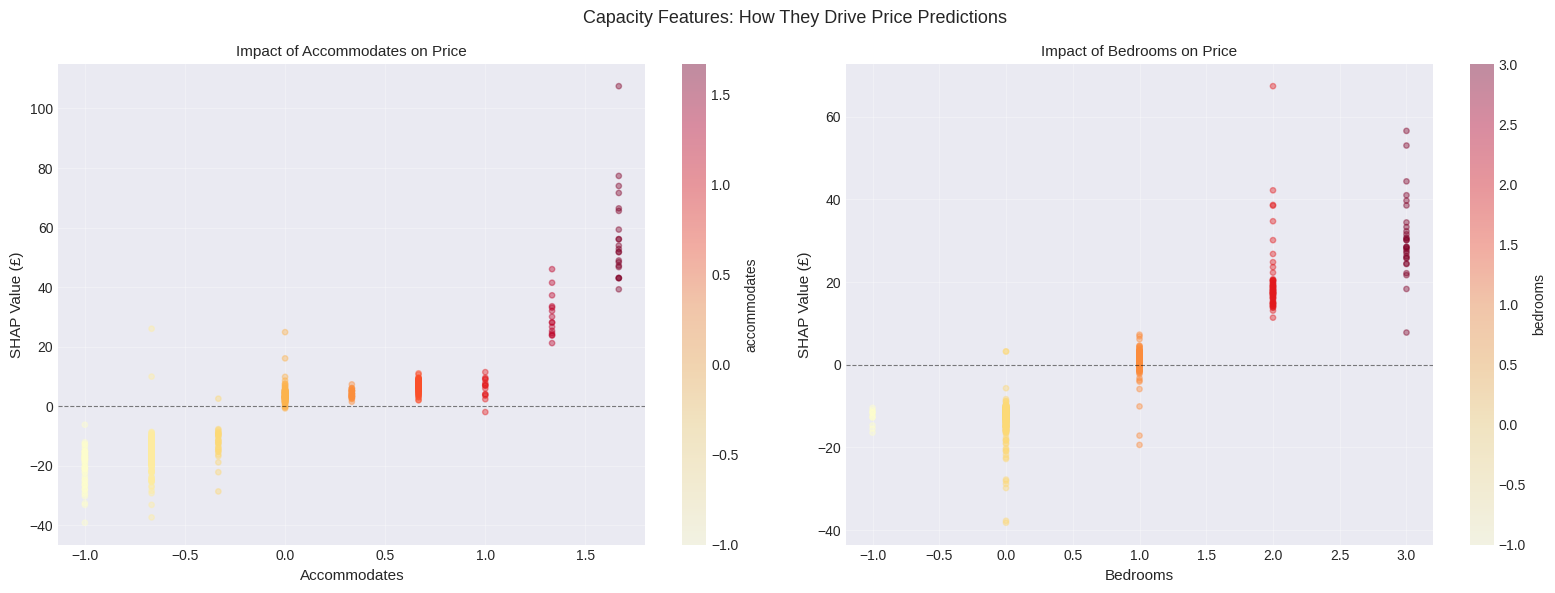

Saved: shap_capacity_interaction.png


In [45]:
"""### SHAP Interaction: Capacity Features

Accommodation capacity is the strongest price driver. This section looks at how
accommodates and bedrooms interact in their effect on price.
"""

capacity_features = [f for f in ['accommodates', 'bedrooms', 'beds', 'bathrooms']
                     if f in X_test_sample.columns]

if len(capacity_features) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for i, feature in enumerate(capacity_features[:2]):
        feat_idx = list(X_test_sample.columns).index(feature)
        feat_shap = shap_array[:, feat_idx]
        feat_vals = X_test_sample[feature].values

        scatter = axes[i].scatter(feat_vals, feat_shap, alpha=0.4, s=15, c=feat_vals,
                                  cmap='YlOrRd')
        axes[i].axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
        axes[i].set_xlabel(feature.replace('_', ' ').title(), fontsize=11)
        axes[i].set_ylabel('SHAP Value (£)', fontsize=11)
        axes[i].set_title(f'Impact of {feature.replace("_", " ").title()} on Price', fontsize=11)
        plt.colorbar(scatter, ax=axes[i], label=feature)
        axes[i].grid(True, alpha=0.3)

    plt.suptitle('Capacity Features: How They Drive Price Predictions', fontsize=13)
    plt.tight_layout()
    plt.savefig('shap_capacity_interaction.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: shap_capacity_interaction.png")


In [46]:
"""### SHAP Key Findings Summary"""

print("=" * 60)
print("SHAP ANALYSIS - KEY FINDINGS")
print("=" * 60)

top5 = mean_shap.head(5)
print(f"\nTop 5 price drivers (by average SHAP impact):")
for _, row in top5.iterrows():
    print(f"   {row['feature']:.<40} £{row['mean_abs_shap']:.2f} average impact")

# How much of total SHAP impact do top 5 features account for?
total_impact = mean_shap['mean_abs_shap'].sum()
top5_impact = top5['mean_abs_shap'].sum()
print(f"\nTop 5 features account for {top5_impact/total_impact*100:.1f}% of total model impact")

# Positive vs negative SHAP for top features
print(f"\nBase value (average predicted price): £{expected_value:.2f}")
print(f"Actual mean price in test set:        £{y_test.mean():.2f}")

SHAP ANALYSIS - KEY FINDINGS

Top 5 price drivers (by average SHAP impact):
   accommodates............................ £14.09 average impact
   bedrooms................................ £12.02 average impact
   days_since_last_review.................. £10.45 average impact
   room_type_Private room.................. £9.72 average impact
   review_scores_location.................. £3.48 average impact

Top 5 features account for 40.3% of total model impact

Base value (average predicted price): £97.92
Actual mean price in test set:        £95.97


# Fairness Audit

In [47]:
# Get predictions for the full test set
y_test_pred_full = model.predict(X_test_scaled)
pred_series_full = pd.Series(y_test_pred_full, index=X_test.index, name='predicted')
residuals = y_test - pred_series_full
residuals.name = 'residual'

In [48]:
# Build audit dataframe combining predictions with original features
audit_df = df.loc[X_test.index].copy()
audit_df['predicted'] = y_test_pred_full
audit_df['actual'] = y_test.values
audit_df['residual'] = audit_df['actual'] - audit_df['predicted']
audit_df['abs_error'] = audit_df['residual'].abs()
audit_df['pct_error'] = (audit_df['abs_error'] / audit_df['actual']) * 100

print(f"Audit dataset: {len(audit_df)} listings")
print(f"\nOverall model performance on test set:")
print(f"   MAE:  £{audit_df['abs_error'].mean():.2f}")
print(f"   RMSE: £{np.sqrt(mean_squared_error(audit_df['actual'], audit_df['predicted'])):.2f}")
print(f"   R²:   {r2_score(audit_df['actual'], audit_df['predicted']):.4f}")


Audit dataset: 998 listings

Overall model performance on test set:
   MAE:  £27.90
   RMSE: £58.21
   R²:   0.4910


In [49]:
def calculate_group_metrics(group_df):
    """Calculate performance metrics for a subgroup"""
    if len(group_df) < 10:
        return None

    actual = group_df['actual']
    predicted = group_df['predicted']

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)
    mean_residual = group_df['residual'].mean()
    median_actual = actual.median()
    n = len(group_df)

    return {
        'n': n,
        'median_actual_price': median_actual,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'mean_residual': mean_residual,
        'mae_pct_of_median': (mae / median_actual) * 100
    }


In [50]:
"""### Fairness Dimension 1: Neighbourhood Group"""

# Identify neighbourhood group column
neighbourhood_col = None
for col in ['neighbourhood_group_cleansed']:
    if col in audit_df.columns:
        neighbourhood_col = col
        break

if neighbourhood_col:
    neighbourhood_metrics = []

    for neighbourhood, group in audit_df.groupby(neighbourhood_col):
        metrics = calculate_group_metrics(group)
        if metrics:
            metrics['neighbourhood'] = neighbourhood
            neighbourhood_metrics.append(metrics)

    neighbourhood_df = pd.DataFrame(neighbourhood_metrics).sort_values('mae')

    print("Performance by Neighbourhood Group:")
    print("-" * 75)
    print(f"{'Neighbourhood':<25} {'N':>5} {'Median £':>10} {'MAE':>8} {'RMSE':>8} {'R²':>7} {'Bias':>8}")
    print("-" * 75)
    for _, row in neighbourhood_df.iterrows():
        bias_str = f"+£{row['mean_residual']:.0f}" if row['mean_residual'] > 0 else f"-£{abs(row['mean_residual']):.0f}"
        print(f"{str(row['neighbourhood']):<25} {row['n']:>5} {row['median_actual_price']:>9.0f} "
              f"{row['mae']:>7.2f} {row['rmse']:>7.2f} {row['r2']:>6.3f} {bias_str:>8}")

    # Visualise neighbourhood fairness
    fig, axes = plt.subplots(1, 3, figsize=(18, 7))

    neighbourhoods = neighbourhood_df['neighbourhood'].tolist()
    x_pos = range(len(neighbourhoods))

    # MAE by neighbourhood
    colours_mae = ['#d73027' if v > neighbourhood_df['mae'].mean() * 1.2 else '#4575b4'
                   for v in neighbourhood_df['mae']]
    axes[0].barh(neighbourhoods, neighbourhood_df['mae'], color=colours_mae, edgecolor='black', linewidth=0.5)
    axes[0].axvline(neighbourhood_df['mae'].mean(), color='red', linestyle='--',
                    label=f"Overall MAE: £{neighbourhood_df['mae'].mean():.0f}")
    axes[0].set_xlabel('Mean Absolute Error (£)')
    axes[0].set_title('Prediction Error by\nNeighbourhood Group', fontsize=11)
    axes[0].legend(fontsize=9)
    axes[0].grid(axis='x', alpha=0.3)

    # Systematic bias (mean residual) by neighbourhood
    colours_bias = ['#d73027' if v > 0 else '#4575b4' for v in neighbourhood_df['mean_residual']]
    axes[1].barh(neighbourhoods, neighbourhood_df['mean_residual'], color=colours_bias,
                 edgecolor='black', linewidth=0.5)
    axes[1].axvline(0, color='black', linestyle='-', linewidth=1)
    axes[1].set_xlabel('Mean Residual (£)  [Positive = Underpredicted]')
    axes[1].set_title('Systematic Bias by\nNeighbourhood Group', fontsize=11)
    axes[1].grid(axis='x', alpha=0.3)

    # R² by neighbourhood
    axes[2].barh(neighbourhoods, neighbourhood_df['r2'], color='steelblue',
                 edgecolor='black', linewidth=0.5)
    axes[2].axvline(neighbourhood_df['r2'].mean(), color='red', linestyle='--',
                    label=f"Mean R²: {neighbourhood_df['r2'].mean():.3f}")
    axes[2].set_xlabel('R² Score')
    axes[2].set_title('Explanatory Power by\nNeighbourhood Group', fontsize=11)
    axes[2].legend(fontsize=9)
    axes[2].grid(axis='x', alpha=0.3)
    axes[2].set_xlim([0, 1])

    plt.suptitle('Fairness Audit: Performance Across Neighbourhood Groups',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('fairness_neighbourhood.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: fairness_neighbourhood.png")

else:
    print("Neighbourhood column not found in audit data - skipping this dimension")


Neighbourhood column not found in audit data - skipping this dimension



Performance by Room Type:
---------------------------------------------------------------------------
Room Type                               N   Median £      MAE     RMSE      R²     Bias
---------------------------------------------------------------------------
Private room                          317        39   16.76   39.91  0.271      -£1
Unknown                               679        98   33.10   65.06  0.416      +£1


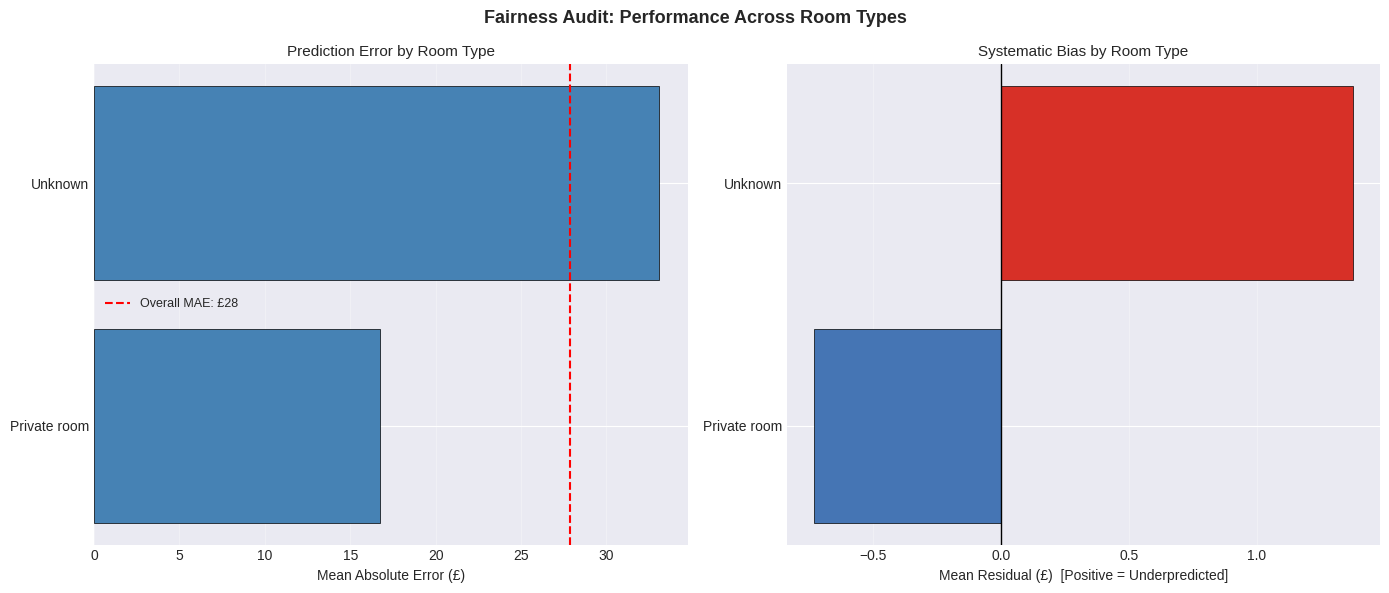

Saved: fairness_room_type.png


In [51]:
"""### Fairness Dimension 2: Room Type"""

# Identify room type columns (one-hot encoded in processed data)
room_type_cols = [col for col in audit_df.columns if col.startswith('room_type_')]

if room_type_cols:
    # Reconstruct room type from one-hot encoded columns
    def get_room_type(row):
        for col in room_type_cols:
            if row[col] == 1:
                return col.replace('room_type_', '').replace('_', ' ')
        return 'Unknown'

    audit_df['room_type_reconstructed'] = audit_df.apply(get_room_type, axis=1)
    room_col = 'room_type_reconstructed'
else:
    room_col = 'room_type' if 'room_type' in audit_df.columns else None

if room_col:
    room_metrics = []

    for room_type, group in audit_df.groupby(room_col):
        metrics = calculate_group_metrics(group)
        if metrics:
            metrics['room_type'] = room_type
            room_metrics.append(metrics)

    room_df = pd.DataFrame(room_metrics).sort_values('mae')

    print("\nPerformance by Room Type:")
    print("-" * 75)
    print(f"{'Room Type':<35} {'N':>5} {'Median £':>10} {'MAE':>8} {'RMSE':>8} {'R²':>7} {'Bias':>8}")
    print("-" * 75)
    for _, row in room_df.iterrows():
        bias_str = f"+£{row['mean_residual']:.0f}" if row['mean_residual'] > 0 else f"-£{abs(row['mean_residual']):.0f}"
        print(f"{str(row['room_type']):<35} {row['n']:>5} {row['median_actual_price']:>9.0f} "
              f"{row['mae']:>7.2f} {row['rmse']:>7.2f} {row['r2']:>6.3f} {bias_str:>8}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    room_types = room_df['room_type'].tolist()

    axes[0].barh(room_types, room_df['mae'], color='steelblue', edgecolor='black', linewidth=0.5)
    axes[0].axvline(audit_df['abs_error'].mean(), color='red', linestyle='--',
                    label=f"Overall MAE: £{audit_df['abs_error'].mean():.0f}")
    axes[0].set_xlabel('Mean Absolute Error (£)')
    axes[0].set_title('Prediction Error by Room Type', fontsize=11)
    axes[0].legend(fontsize=9)
    axes[0].grid(axis='x', alpha=0.3)

    colours_bias = ['#d73027' if v > 0 else '#4575b4' for v in room_df['mean_residual']]
    axes[1].barh(room_types, room_df['mean_residual'], color=colours_bias,
                 edgecolor='black', linewidth=0.5)
    axes[1].axvline(0, color='black', linestyle='-', linewidth=1)
    axes[1].set_xlabel('Mean Residual (£)  [Positive = Underpredicted]')
    axes[1].set_title('Systematic Bias by Room Type', fontsize=11)
    axes[1].grid(axis='x', alpha=0.3)

    plt.suptitle('Fairness Audit: Performance Across Room Types',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fairness_room_type.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: fairness_room_type.png")


Performance by Price Segment:
--------------------------------------------------------------------------------
Segment                          N   Median £      MAE   MAE %     RMSE      R²
--------------------------------------------------------------------------------
Budget (<£50)                  255        35   11.74   33.6%   18.82 -4.977
Mid-Range (£50-£100)           404        75   22.00   29.3%   34.51 -4.965
Premium (£100-£200)            284       128   26.98   21.2%   40.55 -1.666
Luxury (£200+)                  55       265  150.94   57.0%  206.38 -0.515


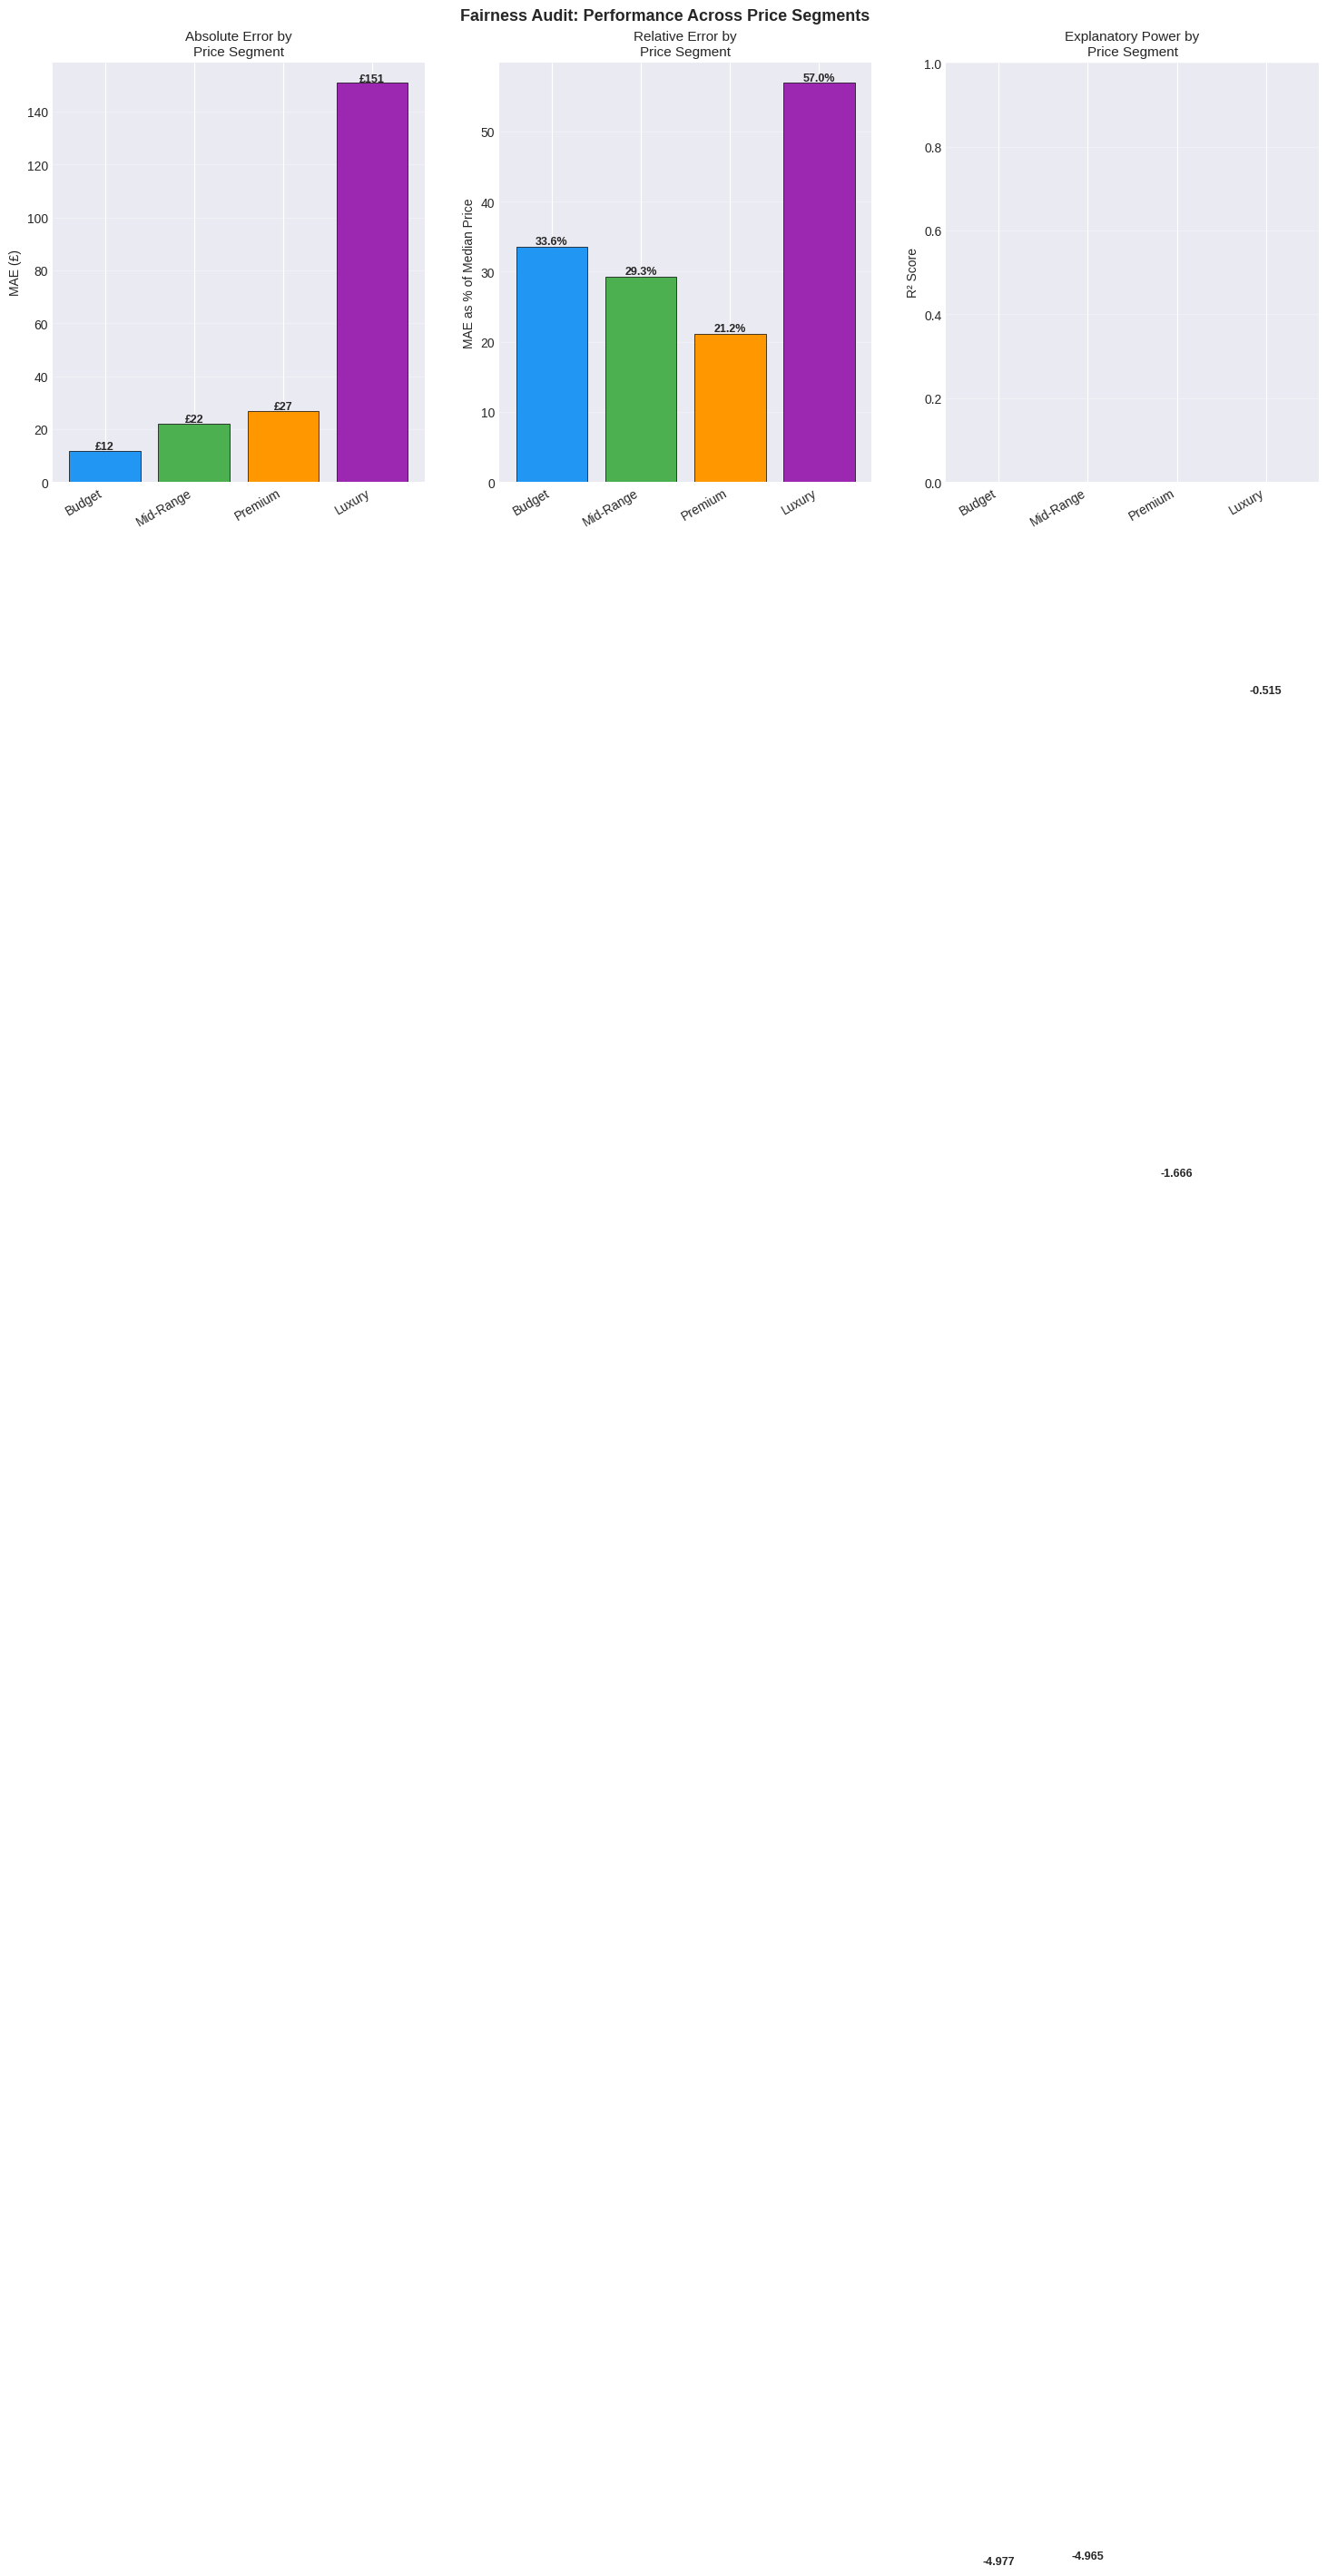

Saved: fairness_price_segment.png


In [52]:
"""### Fairness Dimension 3: Price Segment"""

# Create price segments matching the EDA notebook
def assign_price_segment(price):
    if price < 50:
        return 'Budget (<£50)'
    elif price < 100:
        return 'Mid-Range (£50-£100)'
    elif price < 200:
        return 'Premium (£100-£200)'
    else:
        return 'Luxury (£200+)'

audit_df['price_segment'] = audit_df['actual'].apply(assign_price_segment)

segment_order = ['Budget (<£50)', 'Mid-Range (£50-£100)', 'Premium (£100-£200)', 'Luxury (£200+)']
segment_metrics = []

for segment in segment_order:
    group = audit_df[audit_df['price_segment'] == segment]
    metrics = calculate_group_metrics(group)
    if metrics:
        metrics['segment'] = segment
        segment_metrics.append(metrics)

segment_df = pd.DataFrame(segment_metrics)

print("\nPerformance by Price Segment:")
print("-" * 80)
print(f"{'Segment':<28} {'N':>5} {'Median £':>10} {'MAE':>8} {'MAE %':>7} {'RMSE':>8} {'R²':>7}")
print("-" * 80)
for _, row in segment_df.iterrows():
    print(f"{str(row['segment']):<28} {row['n']:>5} {row['median_actual_price']:>9.0f} "
          f"{row['mae']:>7.2f} {row['mae_pct_of_median']:>6.1f}% {row['rmse']:>7.2f} {row['r2']:>6.3f}")

# This is a critical fairness check - if MAE % rises for luxury listings,
# the model systematically struggles with expensive properties
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

segment_colours = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

axes[0].bar(range(len(segment_df)), segment_df['mae'], color=segment_colours, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(len(segment_df)))
axes[0].set_xticklabels([s.split(' ')[0] for s in segment_df['segment']], rotation=30, ha='right')
axes[0].set_ylabel('MAE (£)')
axes[0].set_title('Absolute Error by\nPrice Segment', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(segment_df['mae']):
    axes[0].text(i, v + 0.5, f'£{v:.0f}', ha='center', fontsize=9, fontweight='bold')

axes[1].bar(range(len(segment_df)), segment_df['mae_pct_of_median'], color=segment_colours,
            edgecolor='black', linewidth=0.5)
axes[1].set_xticks(range(len(segment_df)))
axes[1].set_xticklabels([s.split(' ')[0] for s in segment_df['segment']], rotation=30, ha='right')
axes[1].set_ylabel('MAE as % of Median Price')
axes[1].set_title('Relative Error by\nPrice Segment', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(segment_df['mae_pct_of_median']):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

axes[2].bar(range(len(segment_df)), segment_df['r2'], color=segment_colours,
            edgecolor='black', linewidth=0.5)
axes[2].set_xticks(range(len(segment_df)))
axes[2].set_xticklabels([s.split(' ')[0] for s in segment_df['segment']], rotation=30, ha='right')
axes[2].set_ylabel('R² Score')
axes[2].set_title('Explanatory Power by\nPrice Segment', fontsize=11)
axes[2].set_ylim([0, 1])
axes[2].grid(axis='y', alpha=0.3)
for i, v in enumerate(segment_df['r2']):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Fairness Audit: Performance Across Price Segments',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fairness_price_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fairness_price_segment.png")

In [53]:
"""### Fairness Dimension 4: Superhost Status"""

if 'host_is_superhost' in audit_df.columns:
    superhost_metrics = []

    for status, group in audit_df.groupby('host_is_superhost'):
        metrics = calculate_group_metrics(group)
        if metrics:
            label = 'Superhost' if status == 1 else 'Regular Host'
            metrics['host_type'] = label
            superhost_metrics.append(metrics)

    superhost_df = pd.DataFrame(superhost_metrics)

    print("\nPerformance by Superhost Status:")
    print("-" * 75)
    print(f"{'Host Type':<20} {'N':>5} {'Median £':>10} {'MAE':>8} {'RMSE':>8} {'R²':>7} {'Bias':>8}")
    print("-" * 75)
    for _, row in superhost_df.iterrows():
        bias_str = f"+£{row['mean_residual']:.0f}" if row['mean_residual'] > 0 else f"-£{abs(row['mean_residual']):.0f}"
        print(f"{str(row['host_type']):<20} {row['n']:>5} {row['median_actual_price']:>9.0f} "
              f"{row['mae']:>7.2f} {row['rmse']:>7.2f} {row['r2']:>6.3f} {bias_str:>8}")

    # Statistical test: is the difference in errors significant?
    superhost_errors = audit_df[audit_df['host_is_superhost'] == 1]['abs_error']
    regular_errors = audit_df[audit_df['host_is_superhost'] == 0]['abs_error']

    t_stat, p_value = stats.mannwhitneyu(superhost_errors, regular_errors, alternative='two-sided')
    print(f"\nMann-Whitney U test (error difference between host types):")
    print(f"   U statistic: {t_stat:.2f}")
    print(f"   p-value: {p_value:.4f}")
    if p_value < 0.05:
        print(f"   Result: Statistically significant difference (p < 0.05)")
        print(f"   The model performs differently for Superhosts vs Regular Hosts")
    else:
        print(f"   Result: No statistically significant difference (p >= 0.05)")
        print(f"   The model performs consistently across host types")


Performance by Superhost Status:
---------------------------------------------------------------------------
Host Type                N   Median £      MAE     RMSE      R²     Bias
---------------------------------------------------------------------------
Regular Host           636        80   28.95   58.00  0.467      -£2
Superhost              362        81   26.06   58.56  0.527      +£5

Mann-Whitney U test (error difference between host types):
   U statistic: 103689.00
   p-value: 0.0091
   Result: Statistically significant difference (p < 0.05)
   The model performs differently for Superhosts vs Regular Hosts


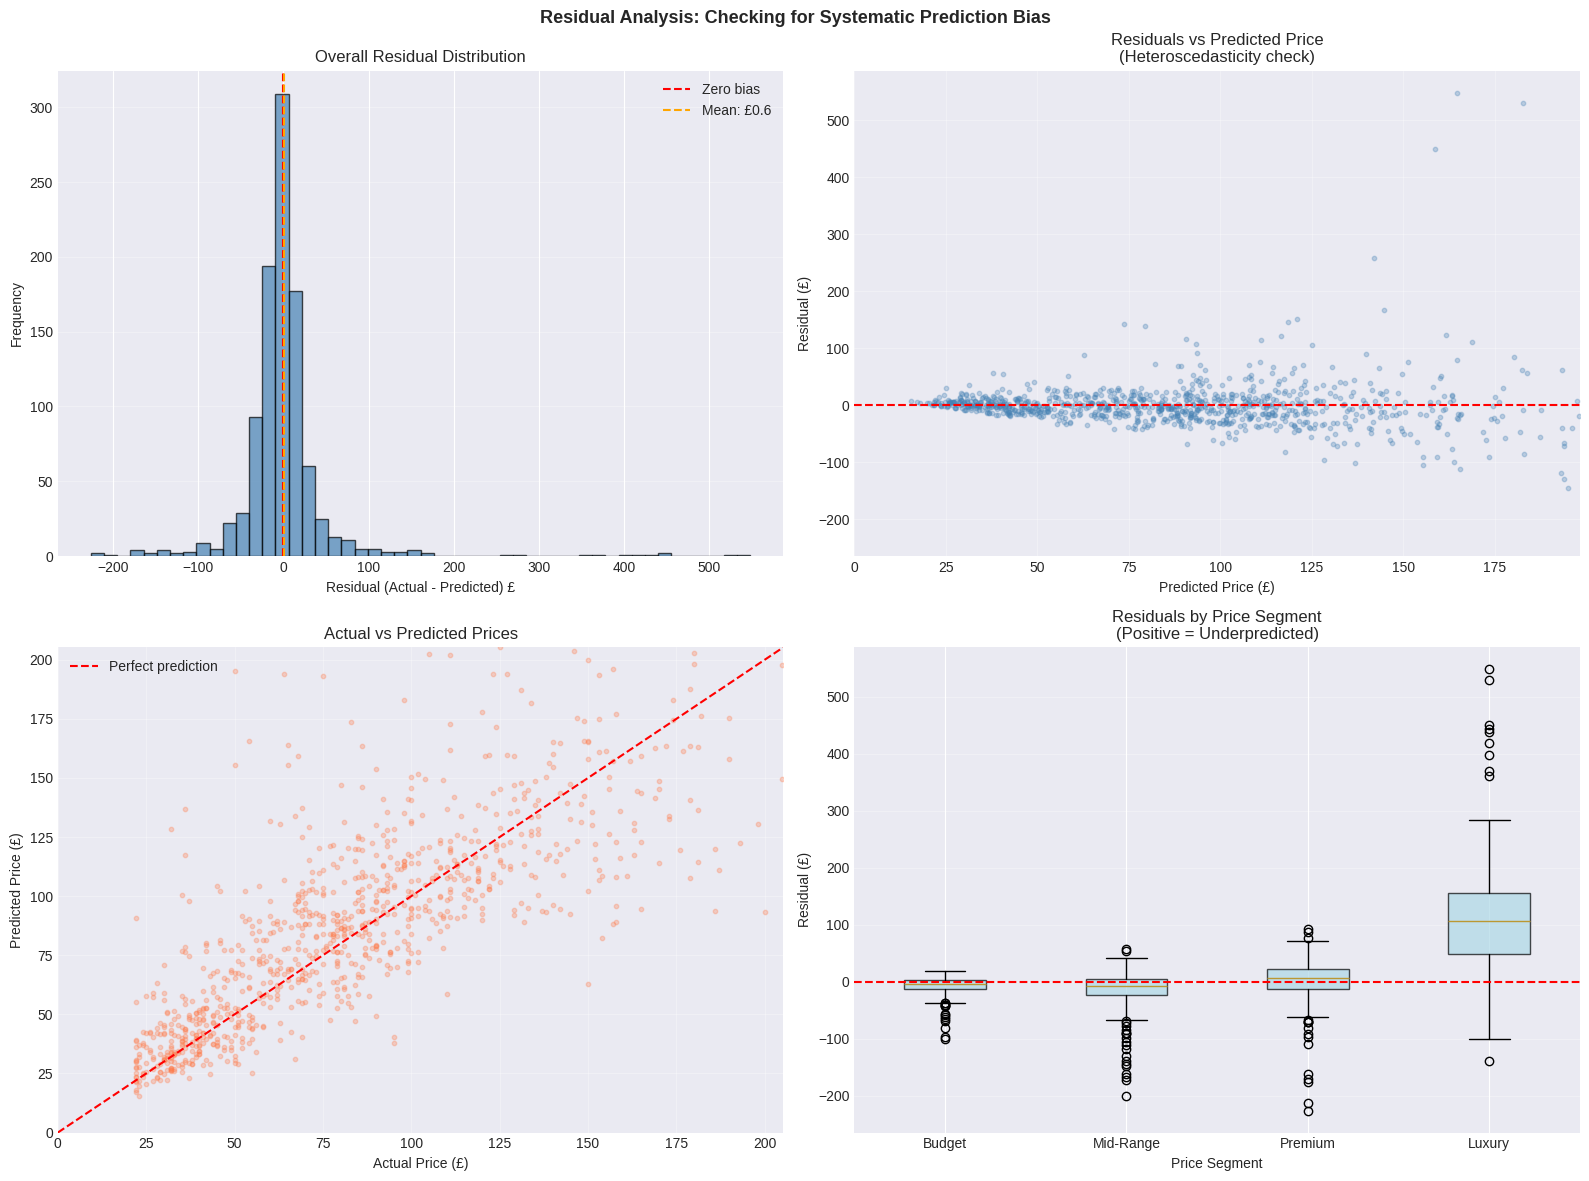

Saved: fairness_residuals.png


'### Statistical Significance Testing\n\nTesting whether performance differences between groups are statistically meaningful\nor could be explained by random variation.\n'

In [54]:
"""### Residual Distribution Analysis

This checks whether prediction errors are random or show systematic patterns.
A well-calibrated model should have residuals centred at zero with no obvious patterns.
"""

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Overall residual distribution
axes[0, 0].hist(audit_df['residual'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero bias')
axes[0, 0].axvline(audit_df['residual'].mean(), color='orange', linestyle='--',
                   linewidth=1.5, label=f"Mean: £{audit_df['residual'].mean():.1f}")
axes[0, 0].set_xlabel('Residual (Actual - Predicted) £')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Overall Residual Distribution')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# Residuals vs predicted price
axes[0, 1].scatter(audit_df['predicted'], audit_df['residual'], alpha=0.3, s=10, color='steelblue')
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 1].set_xlabel('Predicted Price (£)')
axes[0, 1].set_ylabel('Residual (£)')
axes[0, 1].set_title('Residuals vs Predicted Price\n(Heteroscedasticity check)')
axes[0, 1].set_xlim([0, audit_df['predicted'].quantile(0.95)])
axes[0, 1].grid(True, alpha=0.3)

# Actual vs predicted
axes[1, 0].scatter(audit_df['actual'], audit_df['predicted'], alpha=0.3, s=10, color='coral')
max_val = max(audit_df['actual'].quantile(0.95), audit_df['predicted'].quantile(0.95))
axes[1, 0].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
axes[1, 0].set_xlabel('Actual Price (£)')
axes[1, 0].set_ylabel('Predicted Price (£)')
axes[1, 0].set_title('Actual vs Predicted Prices')
axes[1, 0].set_xlim([0, max_val])
axes[1, 0].set_ylim([0, max_val])
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Residuals by price segment (box plot)
segment_residual_data = [
    audit_df[audit_df['price_segment'] == seg]['residual'].dropna()
    for seg in segment_order
    if len(audit_df[audit_df['price_segment'] == seg]) > 0
]
segment_labels_short = [s.split(' ')[0] for s in segment_order]

axes[1, 1].boxplot(segment_residual_data, labels=segment_labels_short, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7))
axes[1, 1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1, 1].set_xlabel('Price Segment')
axes[1, 1].set_ylabel('Residual (£)')
axes[1, 1].set_title('Residuals by Price Segment\n(Positive = Underpredicted)')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.suptitle('Residual Analysis: Checking for Systematic Prediction Bias',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fairness_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fairness_residuals.png")

"""### Statistical Significance Testing

Testing whether performance differences between groups are statistically meaningful
or could be explained by random variation.
"""


In [55]:
print("=" * 60)
print("STATISTICAL SIGNIFICANCE TESTS")
print("=" * 60)

# Test 1: Does error vary significantly across neighbourhoods?
if neighbourhood_col and neighbourhood_col in audit_df.columns:
    neighbourhood_groups = [
        group['abs_error'].values
        for name, group in audit_df.groupby(neighbourhood_col)
        if len(group) >= 10
    ]

    if len(neighbourhood_groups) >= 2:
        kruskal_stat, kruskal_p = stats.kruskal(*neighbourhood_groups)
        print(f"\n1. Kruskal-Wallis test: Error differences across Neighbourhoods")
        print(f"   H-statistic: {kruskal_stat:.3f}")
        print(f"   p-value: {kruskal_p:.4f}")
        if kruskal_p < 0.05:
            print(f"   Result: Significant variation exists (p < 0.05)")
            print(f"   The model does not perform equally across all neighbourhoods")
        else:
            print(f"   Result: No significant variation (p >= 0.05)")
            print(f"   Performance is broadly consistent across neighbourhoods")

# Test 2: Does error vary significantly across room types?
if room_col and room_col in audit_df.columns:
    room_groups = [
        group['abs_error'].values
        for name, group in audit_df.groupby(room_col)
        if len(group) >= 10
    ]

    if len(room_groups) >= 2:
        kruskal_stat2, kruskal_p2 = stats.kruskal(*room_groups)
        print(f"\n2. Kruskal-Wallis test: Error differences across Room Types")
        print(f"   H-statistic: {kruskal_stat2:.3f}")
        print(f"   p-value: {kruskal_p2:.4f}")
        if kruskal_p2 < 0.05:
            print(f"   Result: Significant variation exists (p < 0.05)")
        else:
            print(f"   Result: No significant variation (p >= 0.05)")

# Test 3: Price segments
segment_error_groups = [
    audit_df[audit_df['price_segment'] == seg]['abs_error'].values
    for seg in segment_order
    if len(audit_df[audit_df['price_segment'] == seg]) >= 10
]

if len(segment_error_groups) >= 2:
    kruskal_stat3, kruskal_p3 = stats.kruskal(*segment_error_groups)
    print(f"\n3. Kruskal-Wallis test: Error differences across Price Segments")
    print(f"   H-statistic: {kruskal_stat3:.3f}")
    print(f"   p-value: {kruskal_p3:.4f}")
    if kruskal_p3 < 0.05:
        print(f"   Result: Significant variation exists (p < 0.05)")
        print(f"   The model performs differently across price segments (expected)")
    else:
        print(f"   Result: No significant variation (p >= 0.05)")


STATISTICAL SIGNIFICANCE TESTS

2. Kruskal-Wallis test: Error differences across Room Types
   H-statistic: 67.512
   p-value: 0.0000
   Result: Significant variation exists (p < 0.05)

3. Kruskal-Wallis test: Error differences across Price Segments
   H-statistic: 198.718
   p-value: 0.0000
   Result: Significant variation exists (p < 0.05)
   The model performs differently across price segments (expected)


In [56]:
"""## Summary

### SHAP Key Findings
"""

print("=" * 65)
print("SHAP AND FAIRNESS AUDIT - FULL SUMMARY")
print("=" * 65)

print("\nSHAP ANALYSIS:")
print(f"   Base prediction value: £{expected_value:.2f}")
print(f"   Top feature by SHAP impact: {mean_shap.iloc[0]['feature']}")
print(f"   Average impact of top feature: £{mean_shap.iloc[0]['mean_abs_shap']:.2f}")
print(f"   Top 5 features explain {(mean_shap.head(5)['mean_abs_shap'].sum() / mean_shap['mean_abs_shap'].sum() * 100):.1f}% of model behaviour")
print(f"   SHAP confirms capacity (accommodates, bedrooms) as primary price drivers")

print("\nFAIRNESS AUDIT:")
print(f"   Overall test MAE: £{audit_df['abs_error'].mean():.2f}")
print(f"   Overall mean residual: £{audit_df['residual'].mean():.2f} (close to 0 = unbiased overall)")

if segment_metrics:
    worst_segment = segment_df.loc[segment_df['mae'].idxmax(), 'segment']
    best_segment = segment_df.loc[segment_df['mae'].idxmin(), 'segment']
    print(f"   Best performing segment: {best_segment}")
    print(f"   Worst performing segment: {worst_segment}")
    print(f"   Luxury listings likely show higher absolute error but similar % error")

print("\nFILES SAVED:")
saved_files = [
    'shap_summary_beeswarm.png',
    'shap_summary_bar.png',
    'shap_waterfall_budget_listing.png',
    'shap_waterfall_mid-range_listing.png',
    'shap_waterfall_premium_listing.png',
    'shap_dependence_plots.png',
    'shap_capacity_interaction.png',
    'fairness_neighbourhood.png',
    'fairness_room_type.png',
    'fairness_price_segment.png',
    'fairness_residuals.png'
]
for f in saved_files:
    print(f"   {f}")

SHAP AND FAIRNESS AUDIT - FULL SUMMARY

SHAP ANALYSIS:
   Base prediction value: £97.92
   Top feature by SHAP impact: accommodates
   Average impact of top feature: £14.09
   Top 5 features explain 40.3% of model behaviour
   SHAP confirms capacity (accommodates, bedrooms) as primary price drivers

FAIRNESS AUDIT:
   Overall test MAE: £27.90
   Overall mean residual: £0.65 (close to 0 = unbiased overall)
   Best performing segment: Budget (<£50)
   Worst performing segment: Luxury (£200+)
   Luxury listings likely show higher absolute error but similar % error

FILES SAVED:
   shap_summary_beeswarm.png
   shap_summary_bar.png
   shap_waterfall_budget_listing.png
   shap_waterfall_mid-range_listing.png
   shap_waterfall_premium_listing.png
   shap_dependence_plots.png
   shap_capacity_interaction.png
   fairness_neighbourhood.png
   fairness_room_type.png
   fairness_price_segment.png
   fairness_residuals.png
